In [2]:
# setup_environment.py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, iqr
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 재현성을 위한 랜덤 시드 설정
np.random.seed(42)

# 시각화 스타일 설정 (옵션)
sns.set_theme(style='whitegrid')


In [3]:
# Seaborn 내장 diamonds 데이터셋 로드
df = sns.load_dataset('diamonds')

# 데이터 차원 (행, 열) 확인
print(f"Data Shape: {df.shape}")
# Output: Data Shape: (53940, 10)

# 데이터 기초 정보 확인 (컬럼 타입, 결측치 등)
print(df.info())
# Output:
# price : int64
# carat : float64
# cut, color, clarity : category ...

# 상위 5개 데이터 미리보기
print(df.head())


Data Shape: (53940, 10)
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20

skewness: 1.618395283383529
kurtosis (Pearson): 5.177695759248689


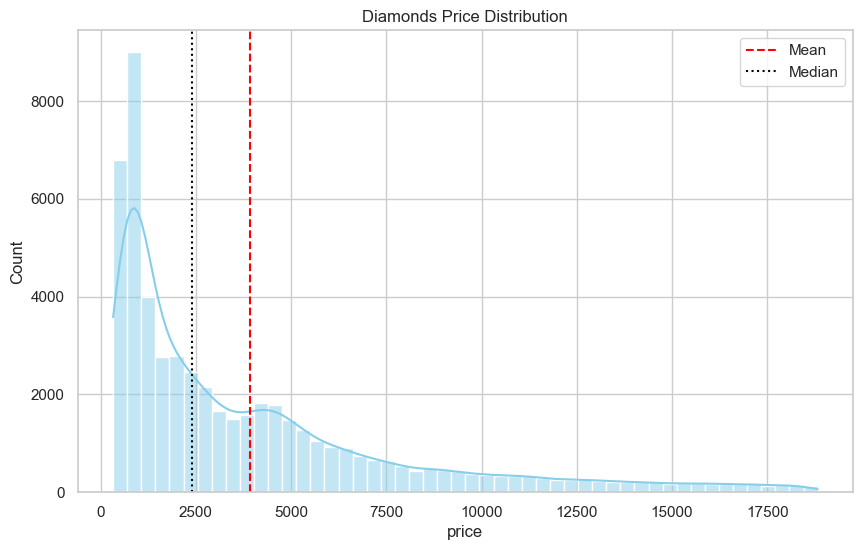

In [4]:
# analyze_distribution.py
# 가격 데이터 추출
price = df['price']

# 왜도(Skewness)와 첨도(Kurtosis) 계산
print('skewness:', skew(price, bias=False))
print('kurtosis (Pearson):', kurtosis(price, fisher=False, bias=False))

# 히스토그램 및 밀도 함수 시각화
plt.figure(figsize=(10, 6))
sns.histplot(price, bins=50, kde=True, color='skyblue')

# 평균과 중앙값 표시
plt.axvline(price.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(price.median(), color='black', linestyle=':', label='Median')

plt.legend()
plt.title('Diamonds Price Distribution')
plt.show()



=== 색상별 가격 분포 특성 ===
   color   level_1     price
0      D  skewness  2.105520
1      D  kurtosis  7.673960
2      E  skewness  2.169836
3      E  kurtosis  7.899241
4      F  skewness  1.754865
5      F  kurtosis  5.820251
6      G  skewness  1.499324
7      G  kurtosis  4.723282
8      H  skewness  1.383031
9      H  kurtosis  4.448713
10     I  skewness  1.158572
11     I  kurtosis  3.421068
12     J  skewness  1.035449
13     J  kurtosis  3.284350


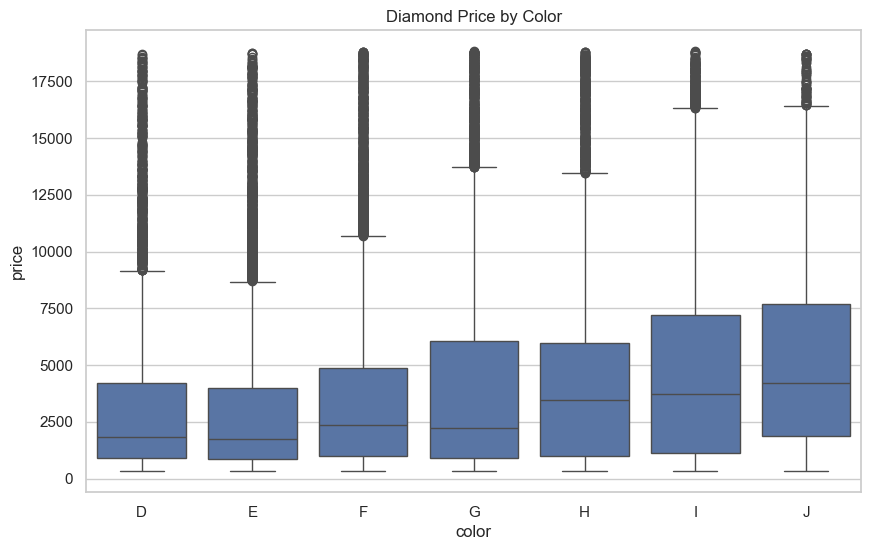

In [ ]:
# 색상(color)별로 가격(price)의 왜도와 첨도를 계산
# apply와 lambda 함수를 사용하여 여러 통계량을 반환
by_color = (df.groupby('color')['price']
            .apply(lambda s: pd.Series({ 
                'skewness': skew(s, bias=False),
                'kurtosis': kurtosis(s, fisher=False, bias=False)
            }))
            .reset_index())

print("=== 색상별 가격 분포 특성 ===")
print(by_color)

# 결과 해석을 위한 Boxplot 시각화 (옵션)
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='price', data=df)
plt.title('Diamond Price by Color')
plt.show()


In [6]:
har_total = pd.read_pickle('/Users/jsh/Desktop/class/3-1/비정형데이터분석/실습/A_DeviceMotion_data 복사본/HAR_total.pkl')

# feature_extraction.py
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def rss(x):
    return np.sqrt(np.sum(np.square(x)))

# 그룹별 다양한 통계량 한 번에 추출
har_summary_extend = (har_total
    .groupby(['id', 'exp_no', 'activity'])
    .agg(
        magAcc_mean=('maguserAcceleration', 'mean'),
        magAcc_sd  =('maguserAcceleration', 'std'),
        magAcc_skew=('maguserAcceleration', lambda x: skew(x, bias=False)),
        magAcc_rms =('maguserAcceleration', rms),
        magAcc_rss =('maguserAcceleration', rss),
        magAcc_iqr =('maguserAcceleration', lambda x: iqr(x, rng=(25, 75))),
        magAcc_kurt=('maguserAcceleration', lambda x: kurtosis(x, fisher=False, bias=False))
    )
    .reset_index()
)
print("Expanded features shape:", har_summary_extend.shape)


Expanded features shape: (360, 10)


In [7]:
# 확장된 요약 데이터프레임의 변수 타입 확인
print("----- 데이터 타입 확인 -----")
print(har_summary_extend.dtypes)

# 문자열이나 범주형 데이터는 'category' 타입으로 변환하는 것이 효율적
# activity 컬럼을 범주형(category)으로 변환
har_summary_extend['activity'] = har_summary_extend['activity'].astype('category')

# 변환 후 데이터 타입 재확인
print("\n----- 변환 후 데이터 타입 -----")
print(har_summary_extend['activity'].dtype)


----- 데이터 타입 확인 -----
id                 str
exp_no             str
activity           str
magAcc_mean    float64
magAcc_sd      float64
magAcc_skew    float64
magAcc_rms     float64
magAcc_rss     float64
magAcc_iqr     float64
magAcc_kurt    float64
dtype: object

----- 변환 후 데이터 타입 -----
category


In [8]:
# 식별자 컬럼(id, exp_no)은 모델 학습에 불필요하므로 제거
# 원본 데이터프레임(har_summary_extend)은 유지하고 새로운 변수에 저장
har_summary_extend2 = har_summary_extend.drop(
    columns=['id', 'exp_no']
)

# 제거 후 데이터 확인
print("Original shape:", har_summary_extend.shape)
print("New shape:", har_summary_extend2.shape)

# 상위 5개 행 출력하여 컬럼 삭제 확인
print("\nFirst 5 rows of modified dataset:")
print(har_summary_extend2.head())

Original shape: (360, 10)
New shape: (360, 8)

First 5 rows of modified dataset:
  activity  magAcc_mean  magAcc_sd  magAcc_skew  magAcc_rms  magAcc_rss  \
0      dws     0.501065   0.262767     1.140624    0.565750   23.673799   
1      dws     0.508985   0.279252     1.499335    0.580483   17.375745   
2      ups     0.480549   0.265723     1.511764    0.549062   17.926694   
3      sit     0.017672   0.015293     5.197941    0.023370    2.370859   
4      std     0.025681   0.017401     1.863807    0.031019    1.567308   

   magAcc_iqr  magAcc_kurt  
0    0.336092     5.204329  
1    0.331943     7.360827  
2    0.343959     8.182422  
3    0.010806    54.387429  
4    0.018296     7.560645  


In [9]:
# 1. 특성(X)과 타겟 변수(y) 분리
X = har_summary_extend2.drop(columns=['activity'])
y = har_summary_extend2['activity']

# 2. 결정트리 분류기 모델 초기화
clf = DecisionTreeClassifier(random_state=42)

# 3. 10-fold Stratified Cross Validation 설정
# 클래스 비율을 유지하며 데이터를 10개로 분할
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 4. 교차 검증 수행 (정확도 평가)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

# 5. 결과 출력
print('Individual CV scores:', scores)
print(f'Mean CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}')

Individual CV scores: [0.72222222 0.61111111 0.75       0.83333333 0.63888889 0.66666667
 0.66666667 0.75       0.75       0.80555556]
Mean CV accuracy: 0.7194 +/- 0.0685


In [11]:
# 특성, 레이블 분리
features = har_summary_extend2.drop(columns=['activity'])
labels = har_summary_extend2['activity']

# 데이터 표준화 (pca 전 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# pca 모델 생성 및 학습
pca = PCA()
pca.fit(X_scaled)

# 설명된 분산 비율 확인
print('Explaned variance ratio (first 5 components):')
print(pca.explained_variance_ratio_[:5])

Explaned variance ratio (first 5 components):
[0.71429397 0.24016008 0.02684506 0.01225415 0.00365559]


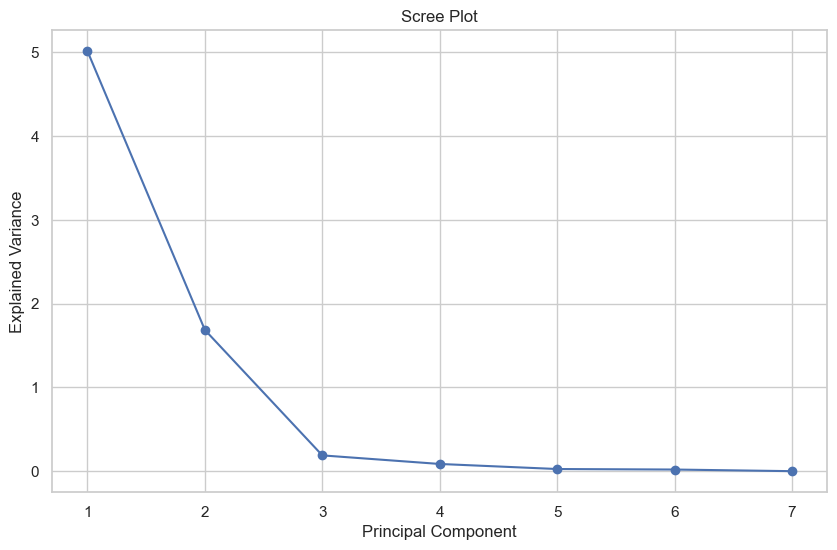

In [15]:
# PCA 모델에서 설명된 분산(고유값) 추출
exp_var = pca.explained_variance_
n_comp = len(exp_var)

#Scree plot 시각화
plt.figure(figsize=(10, 6))
plt.plot(
    np.arange(1, n_comp +1), exp_var, marker='o', linestyle='-'
)

plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.grid(True)
plt.show()

In [19]:
# PCA 로딩스(components) 추출 및 데이터프레임으로 변환
loadings = pd.DataFrame(
    pca.components_.T,
    index = features.columns,
    columns = [f'PC{i+1}' for i in range(pca.n_components_)])

# 결과 확인: 상위 4개 PC의 로딩 값
print('PCA Loadings(First 4 PCs, First 8 features):')
print(loadings.iloc[:8, :4])    

PCA Loadings(First 4 PCs, First 8 features):
                  PC1       PC2       PC3       PC4
magAcc_mean  0.438716  0.115821 -0.170872 -0.062539
magAcc_sd    0.433952  0.127768 -0.237983  0.207952
magAcc_skew -0.210396  0.661795 -0.025529  0.694539
magAcc_rms   0.439587  0.120321 -0.188811  0.012924
magAcc_rss   0.406227  0.112205  0.903644  0.049619
magAcc_iqr   0.436289  0.111060 -0.246550 -0.118815
magAcc_kurt -0.162301  0.702059  0.022503 -0.673584


In [20]:
# PC1 ~ PC3 에서 절대값이 가장 큰 상위 2개 변수 추출
top_vars = {}
for i in range(3):
    pc = f'PC{i+1}'

    # 해당 PC의 로딩 값 절대값 기준으로 상위 2개 변수 추출
    top_vars[pc] = loadings[pc].abs().sort_values(ascending = False).head(2).index.tolist()

print('PC별 상위 변수:', top_vars)

# 추출된 변수들을 하나의 리스트로 통합
selected_features = sorted(set(sum(top_vars.values(), [])))

print('최종 선택 변수:', selected_features)
print(f'선택된 변수 개수: {len(selected_features)}')

PC별 상위 변수: {'PC1': ['magAcc_rms', 'magAcc_mean'], 'PC2': ['magAcc_kurt', 'magAcc_skew'], 'PC3': ['magAcc_rss', 'magAcc_iqr']}
최종 선택 변수: ['magAcc_iqr', 'magAcc_kurt', 'magAcc_mean', 'magAcc_rms', 'magAcc_rss', 'magAcc_skew']
선택된 변수 개수: 6


In [21]:
# 선택된 변수만 추출
X_sel = features[selected_features]

# 분류기 및 cv 설정
clf = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 전체 특질을 사용한 성능 평가
scores_all = cross_val_score(clf, features, labels, cv=cv, scoring='accuracy')

# 선택된 특질(pca 기반)로 성능 평가
scores_sel = cross_val_score(clf, X_sel, labels, cv=cv, scoring='accuracy')

print(f'전체 특질({features.shape[1]}개) CV 정확도: {scores_all.mean():.4f} +/- {scores_all.std():.4f}')
print(f'선택된 특질({X_sel.shape[1]}개) CV 정확도: {scores_sel.mean():.4f} +/- {scores_sel.std():.4f}')

# 성능 차이
diff = scores_sel.mean() - scores_all.mean()
print(f'성능 차이: {diff:.4f} (양수면 선택 특질이 더 우수)')

전체 특질(7개) CV 정확도: 0.7194 +/- 0.0685
선택된 특질(6개) CV 정확도: 0.7389 +/- 0.0544
성능 차이: 0.0194 (양수면 선택 특질이 더 우수)
